# Mortality Biomarker Discovery in Pediatric Critical Influenza Using GSE236877


## Project Overview

This notebook contains the complete Task 1 workflow for identifying mortality-associated gene-expression biomarkers in pediatric critical influenza using **GSE236877**.

### Objective
- Identify mortality-associated genes using differential expression analysis.
- Perform feature selection using the **training set only**.
- Build and evaluate a Random Forest mortality classifier.
- Identify genes with high machine-learning feature importance and integrate them with differential-expression direction.

### Important design choice
Samples from the same patient can occur at multiple time points. Therefore, the train/test split is performed at the **patient level** to prevent patient leakage. Differential-expression feature selection is also performed using the training set only. Cross-validation is performed with patient groups so that repeated samples from one patient are not split across folds.

### Dataset
**GEO accession:** GSE236877  
**Outcome:** mortality (0 = survived, 1 = died)  
**Final ML model:** Random Forest with 500 trees and class balancing.


## 1. Files Extraction


In [3]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [4]:
%%R
# Load the bridge if not already done
# %load_ext rpy2.ipython (Run this in a Python cell if needed)

if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# The 'update = FALSE' and 'ask = FALSE' tells R to just install and not ask questions
BiocManager::install("GEOquery", update = FALSE, ask = FALSE)

library(GEOquery)

# Now proceed with your CFTR dataset
gse <- getGEO("GSE236877", destdir = ".", getGPL = TRUE)
gse_data <- gse[[1]]

# Extract and Save
exp_matrix <- exprs(gse_data)
sample_metadata <- pData(gse_data)
gene_annotations <- fData(gse_data)

write.csv(exp_matrix, "GSE236877_Expression_Matrix.csv")
write.csv(sample_metadata, "GSE236877_Metadata.csv")
write.csv(gene_annotations, "GSE236877_Annotations.csv")

print("Files successfully saved. Check the folder icon on the left.")

[1] "Files successfully saved. Check the folder icon on the left."


Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Found 1 file(s)
GSE236877_series_matrix.txt.gz
Using locally cached version: ./GSE236877_series_matrix.txt.gz
Using locally cached version of GPL33557 found here:
./GPL33557.soft.gz 
In addition: Warning message:
package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'GEOquery' 


## 2. Library Import and Dataset Loading


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# File paths
expression_file = "/content/GSE236877_Expression_Matrix.csv"
metadata_file = "/content/GSE236877_Metadata.csv"
annotation_file = "/content/GSE236877_Annotations.csv"

# Load datasets
expression = pd.read_csv(expression_file)
metadata = pd.read_csv(metadata_file)
annotation = pd.read_csv(annotation_file)

print("Expression matrix:", expression.shape)
print("Metadata:", metadata.shape)
print("Annotation:", annotation.shape)

Expression matrix: (500, 237)
Metadata: (236, 74)
Annotation: (500, 3)


## 3. Dataset Structure and Quality Control


In [6]:
print("========== EXPRESSION MATRIX ==========")
display(expression.head())
print("\nShape:", expression.shape)

print("\n========== METADATA ==========")
display(metadata.head())
print("\nShape:", metadata.shape)

print("\n========== ANNOTATION ==========")
display(annotation.head())
print("\nShape:", annotation.shape)

========== EXPRESSION MATRIX ==========


,Unnamed: 0,GSM7578343,GSM7578344,GSM7578345,GSM7578346,GSM7578347,GSM7578348,GSM7578349,GSM7578350,GSM7578351,...,GSM7578569,GSM7578570,GSM7578571,GSM7578572,GSM7578573,GSM7578574,GSM7578575,GSM7578576,GSM7578577,GSM7578578
0,ACO1,43,16,78,50,19,51,38,7,14,...,43,21,4,47,21,26,14,28,17,22
1,ACOT9,53,129,444,103,109,142,145,118,122,...,145,133,286,119,170,418,80,197,120,162
2,ADM,177,786,1094,129,434,96,337,554,442,...,388,507,1148,335,836,342,374,898,487,652
3,ADORA2A,129,229,107,64,206,76,353,191,203,...,87,98,120,101,126,59,153,143,78,97
4,ADORA2B,11,24,33,13,34,27,32,0,17,...,39,21,3,11,0,14,29,1,32,8



Shape: (500, 237)

========== METADATA ==========


,Unnamed: 0,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,...,previously healthy:ch1,psofa score on day of sample 1:ch1,psofa score on day of sample 2:ch1,sample collection time point:ch1,Sex:ch1,shock requiring vasopressors:ch1,survived?:ch1,tissue:ch1,total hours in icu:ch1,wbc (10^3/ul):ch1
0,GSM7578343,"Patient number 1, Sample Collection Timepoint 1",GSM7578343,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,Yes,11.0,11.0,1,Male,Yes,No,blood,794,0.64
1,GSM7578344,"Patient number 1, Sample Collection Timepoint 2",GSM7578344,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,Yes,11.0,11.0,2,Male,Yes,No,blood,794,0.64
2,GSM7578345,"Patient number 2, Sample Collection Timepoint 1",GSM7578345,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,No,7.0,6.0,1,Male,No,Yes,blood,297,26.39
3,GSM7578346,"Patient number 2, Sample Collection Timepoint 2",GSM7578346,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,No,7.0,6.0,2,Male,No,Yes,blood,297,26.39
4,GSM7578347,"Patient number 3, Sample Collection Timepoint 1",GSM7578347,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,Yes,7.0,6.0,1,Male,Yes,Yes,blood,435,1.44



Shape: (236, 74)

========== ANNOTATION ==========


,Unnamed: 0,ID,SPOT_ID
0,ACO1,ACO1,ACO1
1,ACOT9,ACOT9,ACOT9
2,ADM,ADM,ADM
3,ADORA2A,ADORA2A,ADORA2A
4,ADORA2B,ADORA2B,ADORA2B



Shape: (500, 3)


## 4. Sample and Patient-Level Validation


In [7]:
print(metadata.columns.tolist())

['Unnamed: 0', 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1.1', 'characteristics_ch1.2', 'characteristics_ch1.3', 'characteristics_ch1.4', 'characteristics_ch1.5', 'characteristics_ch1.6', 'characteristics_ch1.7', 'characteristics_ch1.8', 'characteristics_ch1.9', 'characteristics_ch1.10', 'characteristics_ch1.11', 'characteristics_ch1.12', 'characteristics_ch1.13', 'characteristics_ch1.14', 'characteristics_ch1.15', 'characteristics_ch1.16', 'characteristics_ch1.17', 'characteristics_ch1.18', 'characteristics_ch1.19', 'characteristics_ch1.20', 'characteristics_ch1.21', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'taxid_ch1', 'hyb_protocol', 'scan_protocol', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contac

In [8]:
patient_col = "patient number:ch1"

print("Unique patients:",
      metadata[patient_col].nunique())

print("\nSamples per patient:")
display(metadata[patient_col].value_counts().head(20))

Unique patients: 191

Samples per patient:


,count
patient number:ch1,
1,2
2,2
3,2
4,2
5,2
6,2
7,2
8,2
9,2


In [9]:
patient_counts = metadata[patient_col].value_counts()

print("Patients with multiple samples:",
      (patient_counts > 1).sum())

print("Patients with one sample:",
      (patient_counts == 1).sum())

Patients with multiple samples: 45
Patients with one sample: 146


### 5. Mortality distribution


In [10]:
# Mortality distribution
target_col = "survived?:ch1"

print("Survival distribution:")
print(metadata[target_col].value_counts())

# Create binary mortality label
metadata["mortality"] = metadata[target_col].map({
    "Yes": 0,
    "No": 1
})

print("\nMortality distribution:")
print(metadata["mortality"].value_counts())

print("\nMissing mortality labels:",
      metadata["mortality"].isna().sum())

Survival distribution:
survived?:ch1
Yes    220
No      16
Name: count, dtype: int64

Mortality distribution:
mortality
0    220
1     16
Name: count, dtype: int64

Missing mortality labels: 0


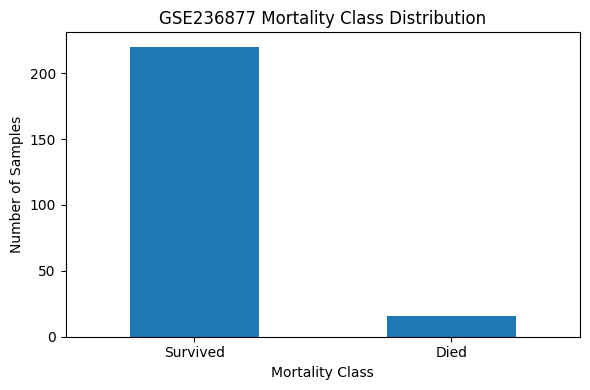

In [11]:
plt.figure(figsize=(6, 4))

metadata["mortality"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mortality Class")
plt.ylabel("Number of Samples")
plt.title("GSE236877 Mortality Class Distribution")

plt.xticks([0, 1], ["Survived", "Died"], rotation=0)

plt.tight_layout()
plt.show()

## 6. Expression Data Quality Control


In [12]:
# Set gene names as index
expression = expression.set_index(expression.columns[0])

# Convert expression values to numeric
expression = expression.apply(pd.to_numeric, errors="coerce")

print("Expression matrix shape:", expression.shape)
print("Missing expression values:", expression.isnull().sum().sum())

Expression matrix shape: (500, 236)
Missing expression values: 0


In [13]:
expression.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
GSM7578343,500.0,1152.746,10058.424061,0.0,7.0,61.0,229.25,202888.0
GSM7578344,500.0,3184.264,34088.636934,0.0,6.0,54.0,281.00,609258.0
GSM7578345,500.0,1528.680,6603.954325,0.0,16.0,107.0,660.00,96009.0
GSM7578346,500.0,494.224,2740.450635,0.0,10.0,73.0,234.50,40618.0
GSM7578347,500.0,1231.184,11585.954806,0.0,8.0,63.0,234.25,237565.0


In [14]:
print("Minimum value:", expression.min().min())
print("Maximum value:", expression.max().max())

integer_values = np.all(
    np.mod(expression.values, 1) == 0
)

print("All values are integers:", integer_values)

Minimum value: 0
Maximum value: 1744837
All values are integers: True


## 7. Expression–Metadata Sample Matching


In [15]:
expression_samples = set(expression.columns)
metadata_samples = set(metadata["geo_accession"])

common_samples = expression_samples.intersection(metadata_samples)

print("Expression samples:", len(expression_samples))
print("Metadata samples:", len(metadata_samples))
print("Common samples:", len(common_samples))

print("\nMissing from metadata:",
      len(expression_samples - metadata_samples))

print("Missing from expression:",
      len(metadata_samples - expression_samples))

Expression samples: 236
Metadata samples: 236
Common samples: 236

Missing from metadata: 0
Missing from expression: 0


## 8. Expression Count Distribution


In [16]:
# Summary statistics of the complete expression matrix

print("Expression matrix shape:", expression.shape)

print("\nOverall expression statistics:")
print(expression.stack().describe())

print("\nNumber of zero values:",
      (expression == 0).sum().sum())

print("Percentage of zero values:",
      (expression == 0).sum().sum() / expression.size * 100)

Expression matrix shape: (500, 236)

Overall expression statistics:
count    1.180000e+05
mean     1.115050e+03
std      1.177381e+04
min      0.000000e+00
25%      8.000000e+00
50%      7.200000e+01
75%      3.010000e+02
max      1.744837e+06
dtype: float64

Number of zero values: 18430
Percentage of zero values: 15.61864406779661


## 9. Gene-Level Expression Quality Control


In [17]:
# Calculate expression statistics for each gene

gene_stats = pd.DataFrame({
    "mean": expression.mean(axis=1),
    "median": expression.median(axis=1),
    "min": expression.min(axis=1),
    "max": expression.max(axis=1),
    "zero_count": (expression == 0).sum(axis=1)
})

gene_stats["zero_percent"] = (
    gene_stats["zero_count"] /
    expression.shape[1] * 100
)

display(gene_stats.head())

,mean,median,min,max,zero_count,zero_percent
Unnamed: 0,,,,,,
ACO1,28.813559,26.0,0,166,9,3.813559
ACOT9,160.402542,126.5,52,840,0,0.000000
ADM,437.177966,390.5,0,1817,1,0.423729
ADORA2A,130.309322,115.0,14,699,0,0.000000
ADORA2B,13.275424,9.0,0,185,38,16.101695


In [18]:
print("Genes with >50% zero expression:",
      (gene_stats["zero_percent"] > 50).sum())

print("Genes with >75% zero expression:",
      (gene_stats["zero_percent"] > 75).sum())

print("Genes with >90% zero expression:",
      (gene_stats["zero_percent"] > 90).sum())

Genes with >50% zero expression: 73
Genes with >75% zero expression: 39
Genes with >90% zero expression: 18


## 10. Sample-Level Expression Quality Control


In [19]:
sample_stats = pd.DataFrame({
    "library_size": expression.sum(axis=0),
    "mean_expression": expression.mean(axis=0),
    "median_expression": expression.median(axis=0),
    "detected_genes": (expression > 0).sum(axis=0)
})

display(sample_stats.describe())

,library_size,mean_expression,median_expression,detected_genes
count,2.360000e+02,236.000000,236.000000,236.000000
mean,5.575248e+05,1115.049585,73.052966,421.906780
std,3.398565e+05,679.712991,13.784988,22.235485
min,1.880110e+05,376.022000,42.000000,340.000000
25%,3.336132e+05,667.226500,64.875000,409.750000
50%,5.057555e+05,1011.511000,72.750000,422.000000
75%,6.887535e+05,1377.507000,80.000000,439.000000
max,3.984966e+06,7969.932000,160.000000,476.000000


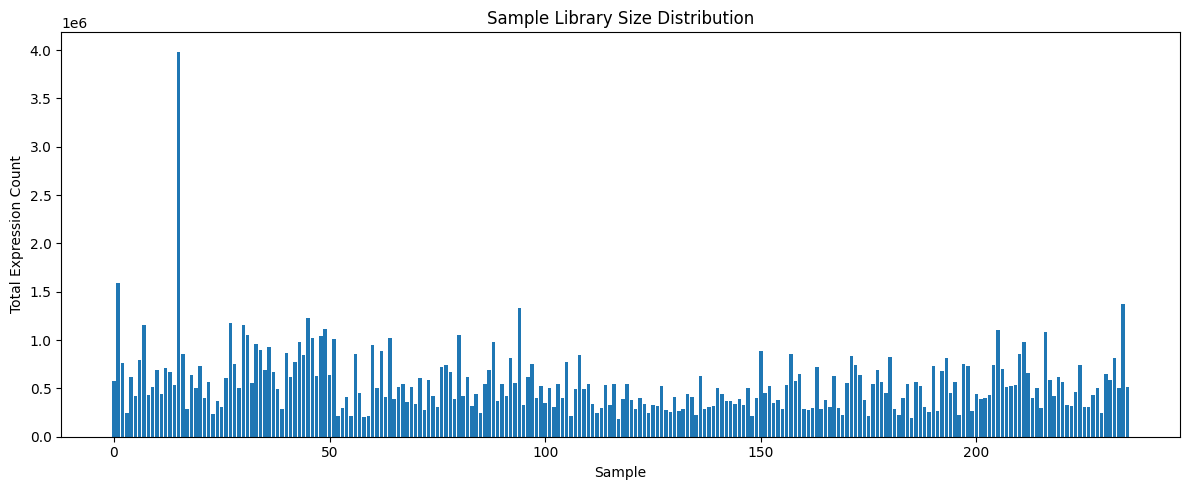

In [20]:
plt.figure(figsize=(12, 5))

plt.bar(
    range(len(sample_stats)),
    sample_stats["library_size"]
)

plt.xlabel("Sample")
plt.ylabel("Total Expression Count")
plt.title("Sample Library Size Distribution")

plt.tight_layout()
plt.show()

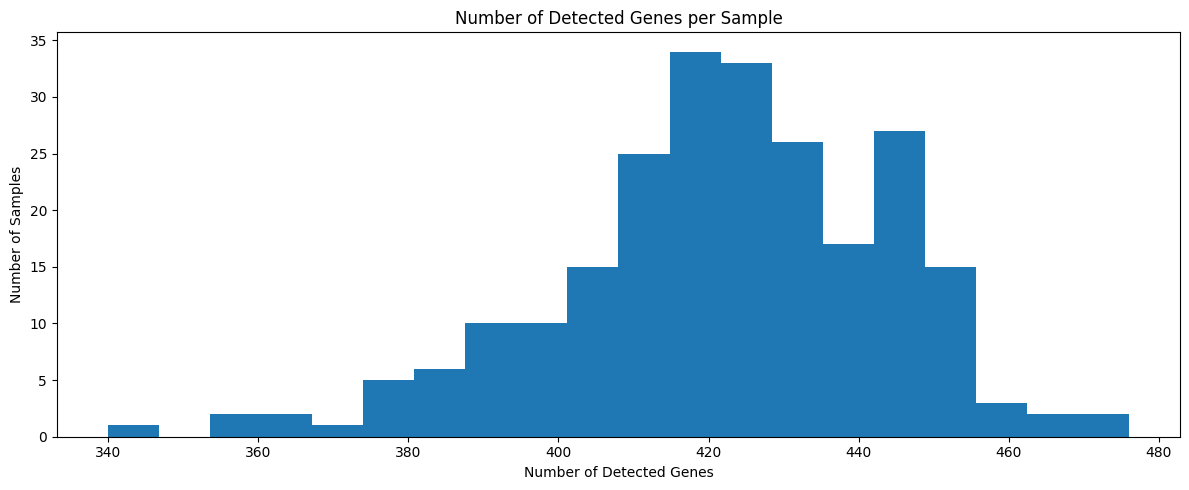

In [21]:
plt.figure(figsize=(12, 5))

plt.hist(
    sample_stats["detected_genes"],
    bins=20
)

plt.xlabel("Number of Detected Genes")
plt.ylabel("Number of Samples")
plt.title("Number of Detected Genes per Sample")

plt.tight_layout()
plt.show()

## 11. Gene Set and Annotation Validation


In [22]:
expression_genes = expression.index.astype(str)
annotation_genes = annotation["ID"].astype(str)

print("Expression genes:", len(expression_genes))
print("Annotation genes:", len(annotation_genes))

print("Common genes:",
      len(set(expression_genes) & set(annotation_genes)))

print("Genes in expression but not annotation:",
      len(set(expression_genes) - set(annotation_genes)))

print("Genes in annotation but not expression:",
      len(set(annotation_genes) - set(expression_genes)))

print("Duplicated expression genes:",
      expression_genes.duplicated().sum())

print("Duplicated annotation IDs:",
      annotation_genes.duplicated().sum())

Expression genes: 500
Annotation genes: 500
Common genes: 500
Genes in expression but not annotation: 0
Genes in annotation but not expression: 0
Duplicated expression genes: 0
Duplicated annotation IDs: 0


In [23]:
# Display annotation structure
print("Annotation columns:")
print(annotation.columns.tolist())

print("\nFirst 10 annotation entries:")
display(annotation.head(10))

Annotation columns:
['Unnamed: 0', 'ID', 'SPOT_ID']

First 10 annotation entries:


,Unnamed: 0,ID,SPOT_ID
0,ACO1,ACO1,ACO1
1,ACOT9,ACOT9,ACOT9
2,ADM,ADM,ADM
3,ADORA2A,ADORA2A,ADORA2A
4,ADORA2B,ADORA2B,ADORA2B
5,ADORA3,ADORA3,ADORA3
6,ADPRH,ADPRH,ADPRH
7,ALAS1,ALAS1,ALAS1
8,ALDOC,ALDOC,ALDOC
9,alpha.hemolysin,alpha.hemolysin,alpha.hemolysin


In [24]:
# Check whether expression gene names are identical to annotation IDs
gene_match = expression_genes.isin(annotation_genes)

print("Expression genes found in annotation:",
      gene_match.sum())

print("Expression genes NOT found in annotation:",
      (~gene_match).sum())

Expression genes found in annotation: 500
Expression genes NOT found in annotation: 0


## 12. Expression Data Preprocessing


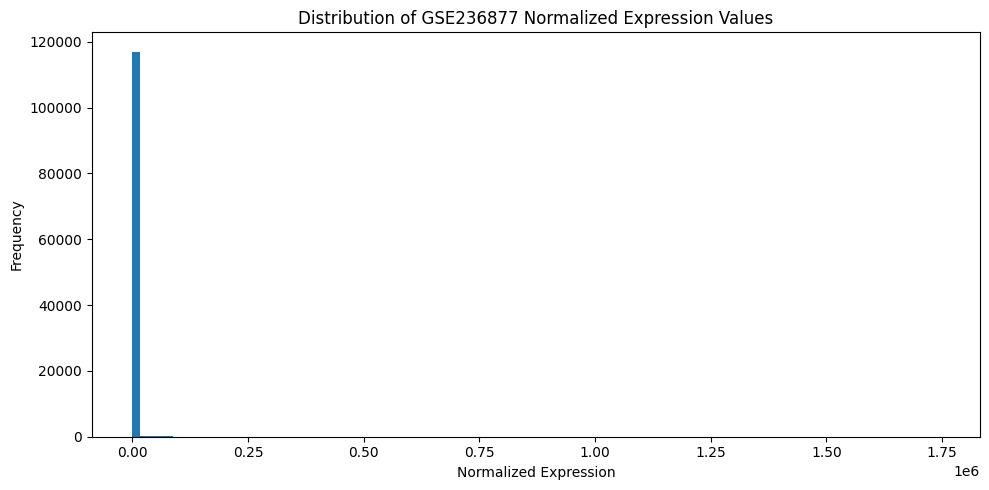

In [25]:
# Expression distribution before transformation

plt.figure(figsize=(10, 5))

plt.hist(
    expression.values.flatten(),
    bins=100
)

plt.xlabel("Normalized Expression")
plt.ylabel("Frequency")
plt.title("Distribution of GSE236877 Normalized Expression Values")

plt.tight_layout()
plt.show()

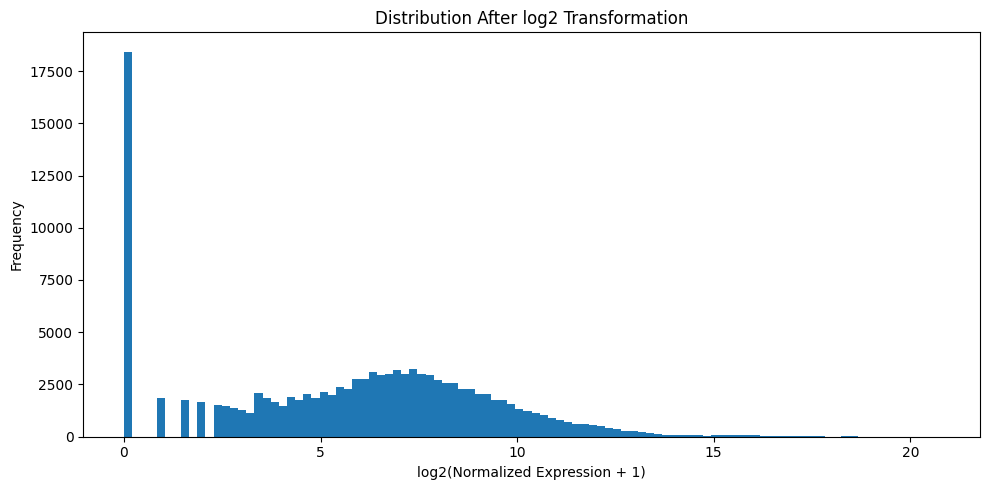

In [26]:
# Log2-transformed distribution for visualization

expression_log2 = np.log2(expression + 1)

plt.figure(figsize=(10, 5))

plt.hist(
    expression_log2.values.flatten(),
    bins=100
)

plt.xlabel("log2(Normalized Expression + 1)")
plt.ylabel("Frequency")
plt.title("Distribution After log2 Transformation")

plt.tight_layout()
plt.show()

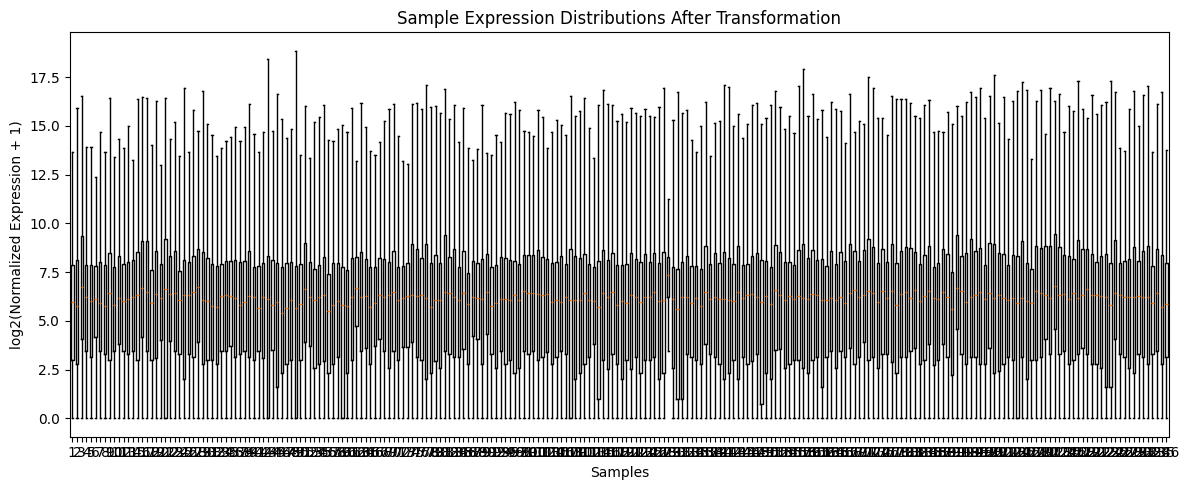

In [27]:
# Sample-level distributions after log2 transformation

plt.figure(figsize=(12, 5))

plt.boxplot(
    expression_log2.values,
    showfliers=False
)

plt.xlabel("Samples")
plt.ylabel("log2(Normalized Expression + 1)")
plt.title("Sample Expression Distributions After Transformation")

plt.tight_layout()
plt.show()

## 13. Log2 Expression Transformation


In [28]:
# Apply log2(x + 1) transformation
expression_log2 = np.log2(expression + 1)

print("Original matrix shape:", expression.shape)
print("Transformed matrix shape:", expression_log2.shape)

print("\nTransformed expression summary:")
display(expression_log2.describe().round(3))

Original matrix shape: (500, 236)
Transformed matrix shape: (500, 236)

Transformed expression summary:


,GSM7578343,GSM7578344,GSM7578345,GSM7578346,GSM7578347,GSM7578348,GSM7578349,GSM7578350,GSM7578351,GSM7578352,...,GSM7578569,GSM7578570,GSM7578571,GSM7578572,GSM7578573,GSM7578574,GSM7578575,GSM7578576,GSM7578577,GSM7578578
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,...,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,5.505,5.647,6.366,5.695,5.583,5.745,5.791,5.640,5.859,5.615,...,5.755,5.588,5.720,5.583,5.937,5.896,5.551,6.142,5.637,5.640
std,3.566,3.686,4.038,3.209,3.554,3.224,3.448,3.488,3.598,3.252,...,3.297,3.627,3.908,3.425,3.640,3.804,3.489,3.490,3.812,3.423
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,3.000,2.807,4.051,3.459,3.170,4.170,3.459,3.322,3.000,3.459,...,3.170,2.585,2.322,3.322,3.170,2.807,3.322,3.459,2.807,3.170
50%,5.954,5.781,6.755,6.209,6.000,6.140,5.931,5.755,6.418,5.807,...,6.209,6.238,6.219,6.267,6.248,6.238,5.931,6.443,5.728,5.858
75%,7.847,8.140,9.369,7.879,7.878,7.827,8.035,7.858,8.493,7.755,...,8.071,8.164,8.798,8.048,8.579,8.856,7.788,8.699,8.401,7.984
max,17.630,19.217,16.551,15.310,17.858,16.627,18.276,18.887,16.446,16.721,...,16.383,17.016,16.768,15.844,17.673,17.063,18.271,16.946,18.861,17.332


## 14. Transformed Expression Quality Check


In [29]:
# Check for problematic values

print("Shape:", expression_log2.shape)

print("Missing values:",
      expression_log2.isna().sum().sum())

print("Infinite values:",
      np.isinf(expression_log2.values).sum())

print("Minimum value:",
      expression_log2.min().min())

print("Maximum value:",
      expression_log2.max().max())

Shape: (500, 236)
Missing values: 0
Infinite values: 0
Minimum value: 0.0
Maximum value: 20.734661664529284


## 15. Save Preprocessed Expression Matrix


In [30]:
import os

os.makedirs("Results", exist_ok=True)

expression_log2.to_csv(
    "Results/GSE236877_expression_log2.csv"
)

metadata.to_csv(
    "Results/GSE236877_metadata_processed.csv",
    index=False
)

print("Preprocessed datasets saved successfully.")

Preprocessed datasets saved successfully.


## 16. Longitudinal Sample and Clinical Information


In [31]:
print(metadata.columns.tolist())

['Unnamed: 0', 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1.1', 'characteristics_ch1.2', 'characteristics_ch1.3', 'characteristics_ch1.4', 'characteristics_ch1.5', 'characteristics_ch1.6', 'characteristics_ch1.7', 'characteristics_ch1.8', 'characteristics_ch1.9', 'characteristics_ch1.10', 'characteristics_ch1.11', 'characteristics_ch1.12', 'characteristics_ch1.13', 'characteristics_ch1.14', 'characteristics_ch1.15', 'characteristics_ch1.16', 'characteristics_ch1.17', 'characteristics_ch1.18', 'characteristics_ch1.19', 'characteristics_ch1.20', 'characteristics_ch1.21', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'taxid_ch1', 'hyb_protocol', 'scan_protocol', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contac

In [32]:
display(
    metadata[
        [
            "geo_accession",
            "patient number:ch1",
            "survived?:ch1"
        ]
    ].head(20)
)

,geo_accession,patient number:ch1,survived?:ch1
0,GSM7578343,1,No
1,GSM7578344,1,No
2,GSM7578345,2,Yes
3,GSM7578346,2,Yes
4,GSM7578347,3,Yes
5,GSM7578348,3,Yes
6,GSM7578349,4,No
7,GSM7578350,4,No
8,GSM7578351,5,Yes
9,GSM7578352,5,Yes


In [33]:
# Patients with repeated samples

patient_counts = metadata["patient number:ch1"].value_counts()

repeated_patients = patient_counts[
    patient_counts > 1
].index

repeated_samples = metadata[
    metadata["patient number:ch1"].isin(repeated_patients)
].sort_values("patient number:ch1")

display(repeated_samples.head(30))

,Unnamed: 0,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,...,psofa score on day of sample 1:ch1,psofa score on day of sample 2:ch1,sample collection time point:ch1,Sex:ch1,shock requiring vasopressors:ch1,survived?:ch1,tissue:ch1,total hours in icu:ch1,wbc (10^3/ul):ch1,mortality
0,GSM7578343,"Patient number 1, Sample Collection Timepoint 1",GSM7578343,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,11.0,11.0,1,Male,Yes,No,blood,794,0.64,1
1,GSM7578344,"Patient number 1, Sample Collection Timepoint 2",GSM7578344,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,11.0,11.0,2,Male,Yes,No,blood,794,0.64,1
2,GSM7578345,"Patient number 2, Sample Collection Timepoint 1",GSM7578345,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,7.0,6.0,1,Male,No,Yes,blood,297,26.39,0
3,GSM7578346,"Patient number 2, Sample Collection Timepoint 2",GSM7578346,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,7.0,6.0,2,Male,No,Yes,blood,297,26.39,0
4,GSM7578347,"Patient number 3, Sample Collection Timepoint 1",GSM7578347,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,7.0,6.0,1,Male,Yes,Yes,blood,435,1.44,0
5,GSM7578348,"Patient number 3, Sample Collection Timepoint 2",GSM7578348,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,7.0,6.0,2,Male,Yes,Yes,blood,435,1.44,0
6,GSM7578349,"Patient number 4, Sample Collection Timepoint 1",GSM7578349,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,14.0,10.0,1,Male,Yes,No,blood,486,0.77,1
7,GSM7578350,"Patient number 4, Sample Collection Timepoint 2",GSM7578350,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,14.0,10.0,2,Male,Yes,No,blood,486,0.77,1
8,GSM7578351,"Patient number 5, Sample Collection Timepoint 1",GSM7578351,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,13.0,8.0,1,Female,No,Yes,blood,1244,6.33,0
9,GSM7578352,"Patient number 5, Sample Collection Timepoint 2",GSM7578352,Public on Jul 07 2023,Jul 07 2023,Jul 07 2023,RNA,1,blood,Homo sapiens,...,13.0,8.0,2,Female,No,Yes,blood,1244,6.33,0


In [34]:
# Display metadata columns that may describe sample timing
time_columns = [
    col for col in metadata.columns
    if any(word in col.lower()
           for word in ["time", "day", "date", "visit", "sample"])
]

print("Potential time/sample columns:")
print(time_columns)

Potential time/sample columns:
['submission_date', 'last_update_date', 'patient had a second sample?:ch1', 'psofa score on day of sample 1:ch1', 'psofa score on day of sample 2:ch1', 'sample collection time point:ch1']


In [35]:
print("Sample collection time points:")
print(
    metadata["sample collection time point:ch1"]
    .value_counts(dropna=False)
)

Sample collection time points:
sample collection time point:ch1
1    191
2     45
Name: count, dtype: int64


In [36]:
print("Second-sample status:")
print(
    metadata["patient had a second sample?:ch1"]
    .value_counts(dropna=False)
)

Second-sample status:
patient had a second sample?:ch1
No     146
Yes     90
Name: count, dtype: int64


In [37]:
# Check whether each patient has a consistent mortality outcome

patient_outcomes = (
    metadata
    .groupby("patient number:ch1")["mortality"]
    .nunique()
)

print("Patients with one consistent mortality outcome:",
      (patient_outcomes == 1).sum())

print("Patients with conflicting mortality outcomes:",
      (patient_outcomes > 1).sum())

Patients with one consistent mortality outcome: 191
Patients with conflicting mortality outcomes: 0


In [38]:
pd.crosstab(
    metadata["sample collection time point:ch1"],
    metadata["mortality"],
    margins=True
)

mortality,0,1,All
sample collection time point:ch1,,,
1,182,9,191
2,38,7,45
All,220,16,236


In [39]:
# Inspect patients who have a second sample

second_sample_patients = metadata[
    metadata["patient had a second sample?:ch1"] == "Yes"
]["patient number:ch1"].unique()

print("Patients with second samples:",
      len(second_sample_patients))

second_samples = metadata[
    metadata["patient number:ch1"].isin(second_sample_patients)
].sort_values(
    ["patient number:ch1",
     "sample collection time point:ch1"]
)

display(
    second_samples[
        [
            "geo_accession",
            "patient number:ch1",
            "sample collection time point:ch1",
            "survived?:ch1",
            "psofa score on day of sample 1:ch1",
            "psofa score on day of sample 2:ch1"
        ]
    ].head(50)
)

Patients with second samples: 45


,geo_accession,patient number:ch1,sample collection time point:ch1,survived?:ch1,psofa score on day of sample 1:ch1,psofa score on day of sample 2:ch1
0,GSM7578343,1,1,No,11.0,11.0
1,GSM7578344,1,2,No,11.0,11.0
2,GSM7578345,2,1,Yes,7.0,6.0
3,GSM7578346,2,2,Yes,7.0,6.0
4,GSM7578347,3,1,Yes,7.0,6.0
5,GSM7578348,3,2,Yes,7.0,6.0
6,GSM7578349,4,1,No,14.0,10.0
7,GSM7578350,4,2,No,14.0,10.0
8,GSM7578351,5,1,Yes,13.0,8.0
9,GSM7578352,5,2,Yes,13.0,8.0


In [40]:
# Check whether every repeated patient has exactly
# one sample at time point 1 and one at time point 2

repeated_structure = (
    second_samples
    .groupby("patient number:ch1")
    ["sample collection time point:ch1"]
    .value_counts()
    .unstack(fill_value=0)
)

print(repeated_structure)

sample collection time point:ch1  1  2
patient number:ch1                    
1                                 1  1
2                                 1  1
3                                 1  1
4                                 1  1
5                                 1  1
6                                 1  1
7                                 1  1
8                                 1  1
9                                 1  1
10                                1  1
11                                1  1
12                                1  1
13                                1  1
14                                1  1
15                                1  1
16                                1  1
17                                1  1
18                                1  1
19                                1  1
20                                1  1
21                                1  1
22                                1  1
23                                1  1
24                       

## 17. Exploratory Differential Expression Analysis


> **Note:** This section is exploratory and uses the broader dataset for visualization and biological inspection. It is **not used for machine-learning feature selection**. The final ML candidate genes are selected exclusively from the training set in Section 20.


17.1 Install R and limma in Google Colab

In [41]:
# Install R and required Bioconductor packages

!apt-get -qq update
!apt-get -qq install r-base

!R -q -e "if (!requireNamespace('BiocManager', quietly=TRUE)) install.packages('BiocManager', repos='https://cloud.r-project.org'); BiocManager::install('limma', ask=FALSE, update=FALSE)"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../r-base-core_4.6.1-2.2204.0_amd64.deb ...
Unpacking r-base-core (4.6.1-2.2204.0) over (4.6.0-4.2204.0) ...
Preparing to unpack .../r-base_4.6.1-2.2204.0_all.deb ...
Unpacking r-base (4.6.1-2.2204.0) over (4.6.0-4.2204.0) ...
Preparing to unpack .../r-recommended_4.6.1-2.2204.0_all.deb ...
Unpacking r-recommended (4.6.1-2.2204.0) over (4.6.0-4.2204.0) ...
Setting up r-base-core (4.6.1-2.2204.0) ...
Installing new version of config file /etc/R/Makeconf ...
Setting up r-recommended (4.6.1-2.2204.0) ...
Setting up r-base (4.6.1-2.2204.0) ...
Processing triggers for hicolor-icon-theme (0.17-2) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...
> if (!require

17.2 Prepare the Data for limma

In [42]:
# Prepare data for differential expression analysis

import pandas as pd
import numpy as np
import os

os.makedirs("Results/DE", exist_ok=True)

# Expression matrix: genes × samples
expression_log2.to_csv(
    "Results/DE/expression_log2.csv"
)

# Clinical metadata
metadata.to_csv(
    "Results/DE/metadata_for_DE.csv",
    index=False
)

print("Expression matrix:", expression_log2.shape)
print("Metadata:", metadata.shape)
print("Files prepared for limma.")

Expression matrix: (500, 236)
Metadata: (236, 75)
Files prepared for limma.


17.3 Run limma

In [43]:
%%writefile Results/DE/run_limma.R

library(limma)

# -----------------------------
# Load data
# -----------------------------

expr <- read.csv(
  "Results/DE/expression_log2.csv",
  row.names = 1,
  check.names = FALSE
)

meta <- read.csv(
  "Results/DE/metadata_for_DE.csv",
  check.names = FALSE
)

# -----------------------------
# Make sure sample order matches
# -----------------------------

sample_ids <- colnames(expr)

meta <- meta[match(sample_ids, meta$geo_accession), ]

stopifnot(all(meta$geo_accession == sample_ids))

# -----------------------------
# Create model variables
# -----------------------------

meta$mortality <- factor(
  meta$mortality,
  levels = c(0, 1),
  labels = c("Survived", "Died")
)

meta$timepoint <- factor(
  meta$`sample collection time point:ch1`
)

meta$patient <- factor(
  meta$`patient number:ch1`
)

# -----------------------------
# Design matrix
# -----------------------------

design <- model.matrix(
  ~ mortality + timepoint,
  data = meta
)

colnames(design) <- make.names(colnames(design))

print("Design matrix:")
print(colnames(design))

# -----------------------------
# Account for repeated patients
# -----------------------------

corfit <- duplicateCorrelation(
  expr,
  design,
  block = meta$patient
)

print("Estimated within-patient correlation:")
print(corfit$consensus)

# -----------------------------
# Fit limma model
# -----------------------------

fit <- lmFit(
  expr,
  design,
  block = meta$patient,
  correlation = corfit$consensus
)

fit <- eBayes(fit)

# -----------------------------
# Mortality-associated genes
# -----------------------------

results <- topTable(
  fit,
  coef = "mortalityDied",
  number = Inf,
  adjust.method = "BH"
)

# Add gene names
results$gene <- rownames(results)

# Reorder columns
results <- results[
  c(
    "gene",
    "logFC",
    "AveExpr",
    "t",
    "P.Value",
    "adj.P.Val",
    "B"
  )
]

# Save results
write.csv(
  results,
  "Results/DE/limma_mortality_results.csv",
  row.names = FALSE
)

print("Differential expression completed.")
print(paste("Genes analyzed:", nrow(results)))

print("Top 10 genes:")
print(head(results, 10))

Writing Results/DE/run_limma.R


In [44]:
!Rscript Results/DE/run_limma.R

[1] "Design matrix:"
[1] "X.Intercept."  "mortalityDied" "timepoint2"   
[1] "Estimated within-patient correlation:"
[1] 0.1549661
[1] "Differential expression completed."
[1] "Genes analyzed: 500"
[1] "Top 10 genes:"
           gene     logFC   AveExpr         t      P.Value    adj.P.Val
PDE4B     PDE4B -1.332882  7.219689 -7.608120 6.604538e-13 3.302269e-10
HLA.DMB HLA.DMB -1.950957  8.194691 -7.414401 2.180200e-12 3.832728e-10
HLADRA   HLADRA -1.931924 10.534420 -7.405680 2.299637e-12 3.832728e-10
MS4A4A   MS4A4A  2.836516  8.020188  7.297009 4.456150e-12 5.570188e-10
GAPDH     GAPDH  1.272253 12.708217  7.245260 6.093647e-12 6.093647e-10
IFIT1     IFIT1 -5.205072  8.282021 -6.598786 2.704136e-10 2.253447e-08
IFIT5     IFIT5 -2.464442  8.722701 -6.490023 5.005749e-10 3.575535e-08
XAF1       XAF1 -3.113838  7.349734 -6.450408 6.253992e-10 3.908745e-08
LY86       LY86 -1.510352  7.945085 -6.396180 8.469954e-10 4.705530e-08
RTP4       RTP4 -3.037837  7.081911 -6.293054 1.500865e-09 6.8

17.4 Load the DE Results Back into Python

In [45]:
# Load limma results

de_results = pd.read_csv(
    "Results/DE/limma_mortality_results.csv"
)

print("DE results shape:", de_results.shape)

display(de_results.head(10))

DE results shape: (500, 7)


,gene,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PDE4B,-1.332882,7.219689,-7.608120,6.604538e-13,3.302269e-10,18.864796
1,HLA.DMB,-1.950957,8.194691,-7.414401,2.180200e-12,3.832728e-10,17.708258
2,HLADRA,-1.931924,10.534420,-7.405680,2.299637e-12,3.832728e-10,17.656625
3,MS4A4A,2.836516,8.020188,7.297009,4.456150e-12,5.570188e-10,17.016333
4,GAPDH,1.272253,12.708217,7.245260,6.093647e-12,6.093647e-10,16.713510
5,IFIT1,-5.205072,8.282021,-6.598786,2.704136e-10,2.253447e-08,13.049077
6,IFIT5,-2.464442,8.722701,-6.490023,5.005749e-10,3.575535e-08,12.455209
7,XAF1,-3.113838,7.349734,-6.450408,6.253992e-10,3.908745e-08,12.240596
8,LY86,-1.510352,7.945085,-6.396180,8.469954e-10,4.705530e-08,11.948296
9,RTP4,-3.037837,7.081911,-6.293054,1.500865e-09,6.843614e-08,11.397214


17.5 Identify Significant Mortality-Associated Genes

In [46]:
# Select significant mortality-associated genes

significant_genes = de_results[
    (de_results["adj.P.Val"] < 0.05) &
    (de_results["logFC"].abs() >= 1)
].copy()

print(
    "Significant mortality-associated genes:",
    len(significant_genes)
)

display(
    significant_genes.sort_values(
        "adj.P.Val"
    ).head(20)
)

Significant mortality-associated genes: 126


,gene,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PDE4B,-1.332882,7.219689,-7.608120,6.604538e-13,3.302269e-10,18.864796
1,HLA.DMB,-1.950957,8.194691,-7.414401,2.180200e-12,3.832728e-10,17.708258
2,HLADRA,-1.931924,10.534420,-7.405680,2.299637e-12,3.832728e-10,17.656625
3,MS4A4A,2.836516,8.020188,7.297009,4.456150e-12,5.570188e-10,17.016333
4,GAPDH,1.272253,12.708217,7.245260,6.093647e-12,6.093647e-10,16.713510
5,IFIT1,-5.205072,8.282021,-6.598786,2.704136e-10,2.253447e-08,13.049077
6,IFIT5,-2.464442,8.722701,-6.490023,5.005749e-10,3.575535e-08,12.455209
7,XAF1,-3.113838,7.349734,-6.450408,6.253992e-10,3.908745e-08,12.240596
8,LY86,-1.510352,7.945085,-6.396180,8.469954e-10,4.705530e-08,11.948296
9,RTP4,-3.037837,7.081911,-6.293054,1.500865e-09,6.843614e-08,11.397214


## 18. Differential Expression Results Visualization


18.1 Volcano Plot

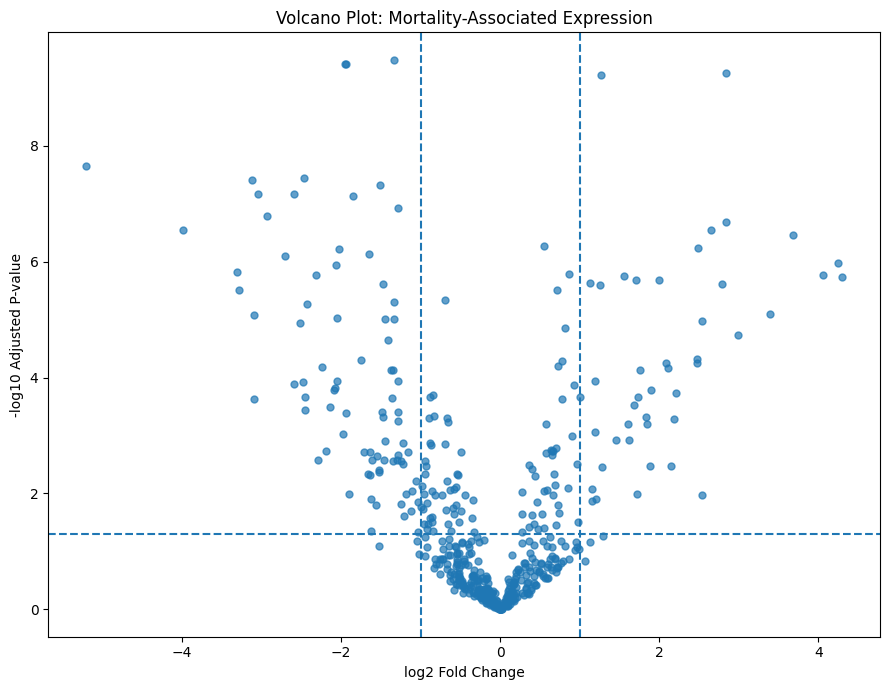

In [47]:
import matplotlib.pyplot as plt
import numpy as np

de_plot = de_results.copy()

de_plot["-log10_adjP"] = -np.log10(
    de_plot["adj.P.Val"]
)

de_plot["significant"] = (
    (de_plot["adj.P.Val"] < 0.05) &
    (de_plot["logFC"].abs() >= 1)
)

plt.figure(figsize=(9, 7))

plt.scatter(
    de_plot["logFC"],
    de_plot["-log10_adjP"],
    s=25,
    alpha=0.7
)

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Volcano Plot: Mortality-Associated Expression")

plt.tight_layout()
plt.show()

18.2 Label the Top 10 Genes

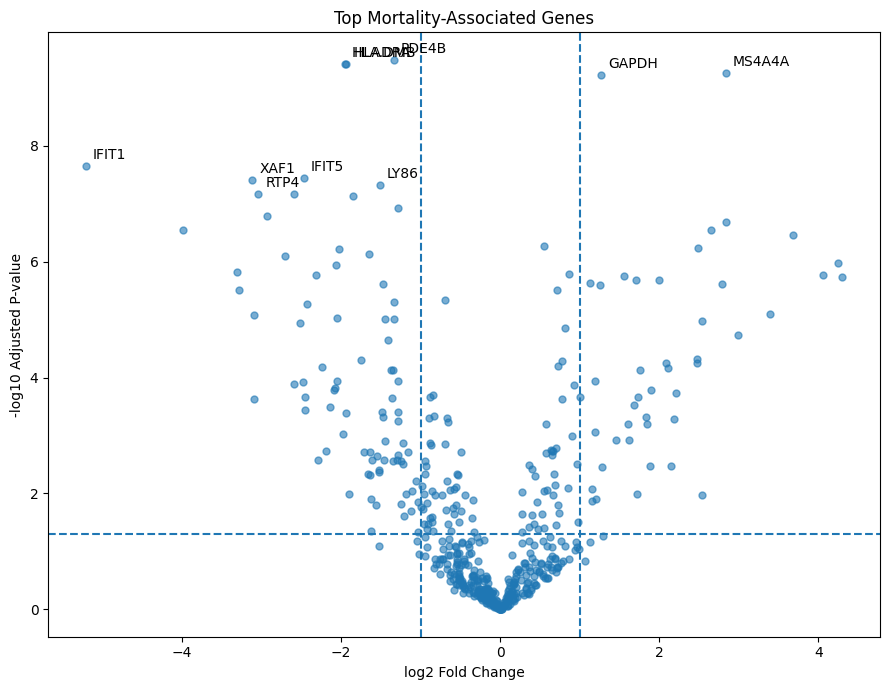

In [48]:
top10 = de_plot.head(10)

plt.figure(figsize=(9, 7))

plt.scatter(
    de_plot["logFC"],
    de_plot["-log10_adjP"],
    s=25,
    alpha=0.6
)

for _, row in top10.iterrows():
    plt.annotate(
        row["gene"],
        (row["logFC"], row["-log10_adjP"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Top Mortality-Associated Genes")

plt.tight_layout()
plt.show()

18.3 Separate Up- and Down-Regulated Genes

In [49]:
upregulated = de_results[
    (de_results["adj.P.Val"] < 0.05) &
    (de_results["logFC"] >= 1)
].copy()

downregulated = de_results[
    (de_results["adj.P.Val"] < 0.05) &
    (de_results["logFC"] <= -1)
].copy()

print("Upregulated in mortality group:", len(upregulated))
print("Downregulated in mortality group:", len(downregulated))
print("Total significant:", len(upregulated) + len(downregulated))

Upregulated in mortality group: 44
Downregulated in mortality group: 82
Total significant: 126


In [50]:
print("\nTop upregulated genes:")
display(
    upregulated.sort_values("adj.P.Val").head(15)
)

print("\nTop downregulated genes:")
display(
    downregulated.sort_values("adj.P.Val").head(15)
)


Top upregulated genes:


,gene,logFC,AveExpr,t,P.Value,adj.P.Val,B
3,MS4A4A,2.836516,8.020188,7.297009,4.456150e-12,5.570188e-10,17.016333
4,GAPDH,1.272253,12.708217,7.245260,6.093647e-12,6.093647e-10,16.713510
14,S100A12,2.843420,13.672462,6.030165,6.271755e-09,2.090585e-07,10.021365
16,BPI,2.647998,7.213490,5.945310,9.862459e-09,2.900723e-07,9.586364
17,LCN2,3.681274,8.261133,5.897642,1.269346e-08,3.525960e-07,9.343988
19,TCN1,2.490473,7.781326,5.780674,2.343719e-08,5.859299e-07,8.755372
23,CD177,4.239545,9.667373,5.627236,5.171052e-08,1.077302e-06,7.996660
27,RETN,4.057407,6.400656,5.506776,9.523274e-08,1.678608e-06,7.411888
29,HK3,1.558606,10.051098,5.482761,1.074410e-07,1.790683e-06,7.296463
30,MMP8,4.298030,8.075405,5.466852,1.163534e-07,1.876667e-06,7.220218



Top downregulated genes:


,gene,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,PDE4B,-1.332882,7.219689,-7.608120,6.604538e-13,3.302269e-10,18.864796
1,HLA.DMB,-1.950957,8.194691,-7.414401,2.180200e-12,3.832728e-10,17.708258
2,HLADRA,-1.931924,10.534420,-7.405680,2.299637e-12,3.832728e-10,17.656625
5,IFIT1,-5.205072,8.282021,-6.598786,2.704136e-10,2.253447e-08,13.049077
6,IFIT5,-2.464442,8.722701,-6.490023,5.005749e-10,3.575535e-08,12.455209
7,XAF1,-3.113838,7.349734,-6.450408,6.253992e-10,3.908745e-08,12.240596
8,LY86,-1.510352,7.945085,-6.396180,8.469954e-10,4.705530e-08,11.948296
9,RTP4,-3.037837,7.081911,-6.293054,1.500865e-09,6.843614e-08,11.397214
10,EPSTI1,-2.591406,9.915233,-6.292484,1.505595e-09,6.843614e-08,11.394184
11,BTN2A2,-1.853217,4.996560,-6.263536,1.765893e-09,7.357886e-08,11.240639


## 19. Patient-Level Train/Test Split


19.1 Create patient-level dataset

In [51]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# --------------------------------------------
# Create one row per patient
# --------------------------------------------

patient_info = (
    metadata[
        [
            "patient number:ch1",
            "mortality"
        ]
    ]
    .drop_duplicates("patient number:ch1")
    .copy()
)

print("Total unique patients:", len(patient_info))

print("\nMortality distribution:")
print(patient_info["mortality"].value_counts())

Total unique patients: 191

Mortality distribution:
mortality
0    182
1      9
Name: count, dtype: int64


19.2 Stratified patient-level split

In [52]:
train_patients, test_patients = train_test_split(
    patient_info["patient number:ch1"],
    test_size=0.20,
    random_state=42,
    stratify=patient_info["mortality"]
)

print("Training patients:", len(train_patients))
print("Testing patients:", len(test_patients))

Training patients: 152
Testing patients: 39


19.3 Check mortality distribution

In [53]:
train_patient_info = patient_info[
    patient_info["patient number:ch1"].isin(train_patients)
]

test_patient_info = patient_info[
    patient_info["patient number:ch1"].isin(test_patients)
]

print("TRAINING SET")
print(train_patient_info["mortality"].value_counts())
print()

print("TEST SET")
print(test_patient_info["mortality"].value_counts())

TRAINING SET
mortality
0    145
1      7
Name: count, dtype: int64

TEST SET
mortality
0    37
1     2
Name: count, dtype: int64


19.4 Convert Patient Split into Sample Split

In [54]:
# Get all samples belonging to training patients
train_samples = metadata[
    metadata["patient number:ch1"].isin(train_patients)
]["geo_accession"].tolist()

# Get all samples belonging to testing patients
test_samples = metadata[
    metadata["patient number:ch1"].isin(test_patients)
]["geo_accession"].tolist()

# Display sample counts
print("Training samples:", len(train_samples))
print("Testing samples:", len(test_samples))
print("Total samples:", len(train_samples) + len(test_samples))

Training samples: 191
Testing samples: 45
Total samples: 236


19.5 Final Patient Leakage Check

In [55]:
# Convert patient IDs to sets
train_patient_set = set(train_patients)
test_patient_set = set(test_patients)

# Find any patients appearing in both sets
overlap = train_patient_set.intersection(test_patient_set)

print("Patients appearing in both sets:", len(overlap))

if len(overlap) == 0:
    print("✓ No patient leakage detected.")
else:
    print("⚠️ WARNING: Patient leakage detected!")
    print("Overlapping patients:", overlap)

Patients appearing in both sets: 0
✓ No patient leakage detected.


## 20. Training-Set-Only Feature Selection


20.1 Prepare Training and Testing Expression Data

In [56]:
# Training expression matrix
X_train_all = expression_log2[train_samples].T.copy()

# Testing expression matrix
X_test_all = expression_log2[test_samples].T.copy()

print("Training expression matrix:", X_train_all.shape)
print("Testing expression matrix:", X_test_all.shape)

Training expression matrix: (191, 500)
Testing expression matrix: (45, 500)


20.2 Create Training and Testing Mortality Labels

In [57]:
# Create metadata indexed by sample ID
metadata_indexed = metadata.set_index("geo_accession")

# Training labels
y_train = metadata_indexed.loc[
    X_train_all.index,
    "mortality"
].astype(int)

# Testing labels
y_test = metadata_indexed.loc[
    X_test_all.index,
    "mortality"
].astype(int)

# Display label distributions
print("TRAINING LABELS")
print(y_train.value_counts())
print()

print("TESTING LABELS")
print(y_test.value_counts())

TRAINING LABELS
mortality
0    178
1     13
Name: count, dtype: int64

TESTING LABELS
mortality
0    42
1     3
Name: count, dtype: int64


In [58]:
print("\nLabel lengths:")
print("y_train:", len(y_train))
print("y_test:", len(y_test))

print("\nExpression/label matching:")
print("Training:", len(X_train_all) == len(y_train))
print("Testing:", len(X_test_all) == len(y_test))


Label lengths:
y_train: 191
y_test: 45

Expression/label matching:
Training: True
Testing: True


### 20.3 Training-Only Differential Expression


20.3.1 Prepare training metadata

In [59]:
# Select metadata for training samples only
train_metadata = metadata[
    metadata["geo_accession"].isin(train_samples)
].copy()

# Match metadata exactly to the expression matrix order
train_metadata = train_metadata.set_index("geo_accession").loc[
    X_train_all.index
].reset_index()

# Verify sample order
print("Training metadata shape:", train_metadata.shape)

print("\nMortality distribution:")
print(train_metadata["mortality"].value_counts())

print("\nTime-point distribution:")
print(
    train_metadata[
        "sample collection time point:ch1"
    ].value_counts()
)

print("\nUnique patients:")
print(
    train_metadata[
        "patient number:ch1"
    ].nunique()
)

Training metadata shape: (191, 75)

Mortality distribution:
mortality
0    178
1     13
Name: count, dtype: int64

Time-point distribution:
sample collection time point:ch1
1    152
2     39
Name: count, dtype: int64

Unique patients:
152


20.3.2 Prepare Training Expression Matrix for DE Analysis

In [60]:
# Make a copy so the original expression data remain unchanged
train_expression = X_train_all.copy()

# Make sure gene names are strings
train_expression.columns = train_expression.columns.astype(str)

# Display dimensions
print("Training expression matrix:")
print("Samples:", train_expression.shape[0])
print("Genes:", train_expression.shape[1])

# Check for missing values
print("\nMissing values:", train_expression.isna().sum().sum())

# Show first few gene names
print("\nFirst 10 genes:")
print(train_expression.columns[:10].tolist())

Training expression matrix:
Samples: 191
Genes: 500

Missing values: 0

First 10 genes:
['ACO1', 'ACOT9', 'ADM', 'ADORA2A', 'ADORA2B', 'ADORA3', 'ADPRH', 'ALAS1', 'ALDOC', 'alpha.hemolysin']


20.3.3 Create Training DE Design Variables

In [61]:
# Make a copy of the relevant training metadata
de_metadata = train_metadata[
    [
        "index", # Changed from "geo_accession" to "index"
        "patient number:ch1",
        "sample collection time point:ch1",
        "mortality"
    ]
].copy()

# Rename columns for easier handling
de_metadata = de_metadata.rename(columns={
    "patient number:ch1": "patient_id",
    "sample collection time point:ch1": "timepoint"
})

# Convert variables to appropriate types
de_metadata["patient_id"] = de_metadata["patient_id"].astype(str)
de_metadata["timepoint"] = de_metadata["timepoint"].astype(str)
de_metadata["mortality"] = de_metadata["mortality"].astype(int)

# Make sure metadata follows exactly the same sample order
# as the training expression matrix
de_metadata = de_metadata.set_index("index").loc[ # Changed from "geo_accession" to "index"
    train_expression.index
].reset_index()

# Display the resulting metadata
print("DE metadata shape:", de_metadata.shape)

print("\nFirst 5 rows:")
print(de_metadata.head())

print("\nMortality:")
print(de_metadata["mortality"].value_counts())

print("\nTime point:")
print(de_metadata["timepoint"].value_counts())

print("\nUnique patients:")
print(de_metadata["patient_id"].nunique())

DE metadata shape: (191, 4)

First 5 rows:
        index patient_id timepoint  mortality
0  GSM7578343          1         1          1
1  GSM7578344          1         2          1
2  GSM7578345          2         1          0
3  GSM7578346          2         2          0
4  GSM7578349          4         1          1

Mortality:
mortality
0    178
1     13
Name: count, dtype: int64

Time point:
timepoint
1    152
2     39
Name: count, dtype: int64

Unique patients:
152


20.3.4 Run Training-Only Differential Expression Analysis

In [62]:
try:
    import rpy2
    print("✓ rpy2 is installed.")
    print("rpy2 version:", rpy2.__version__)
except ImportError:
    print("⚠️ rpy2 is not installed.")

✓ rpy2 is installed.
rpy2 version: 3.5.17


20.3.5 Send Training Data to R

In [63]:
import pandas as pd
import numpy as np

# Import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

# Activate automatic pandas <-> R conversion
pandas2ri.activate()

# --------------------------------------------
# Prepare expression matrix
# --------------------------------------------

# R expects genes as rows and samples as columns
train_expression_r = train_expression.T.copy()

# Make sure gene names are unique
train_expression_r.index = train_expression_r.index.astype(str)

# --------------------------------------------
# Prepare metadata
# --------------------------------------------

train_metadata_r = de_metadata.copy()

# Use sample IDs as row names
train_metadata_r = train_metadata_r.set_index("index")

# Make sure metadata follows exactly the
# same sample order as expression matrix
train_metadata_r = train_metadata_r.loc[
    train_expression_r.columns
]

# --------------------------------------------
# Send objects to R
# --------------------------------------------

ro.globalenv["train_expr"] = pandas2ri.py2rpy(
    train_expression_r
)

ro.globalenv["train_meta"] = pandas2ri.py2rpy(
    train_metadata_r
)

# --------------------------------------------
# Confirmation
# --------------------------------------------

print("✓ Training expression matrix sent to R")
print("Expression shape:", train_expression_r.shape)

print("✓ Training metadata sent to R")
print("Metadata shape:", train_metadata_r.shape)

print("\nSample order matches:",
      list(train_expression_r.columns) ==
      list(train_metadata_r.index))

✓ Training expression matrix sent to R
Expression shape: (500, 191)
✓ Training metadata sent to R
Metadata shape: (191, 3)

Sample order matches: True


20.3.6 Run Training-Only limma Analysis

In [64]:
import rpy2.robjects as ro
from rpy2.robjects import r

# --------------------------------------------
# Load limma
# --------------------------------------------

r("""
library(limma)
""")

# --------------------------------------------
# Prepare variables in R
# --------------------------------------------

r("""
# Convert metadata variables to factors
train_meta$patient_id <- factor(train_meta$patient_id)
train_meta$timepoint <- factor(train_meta$timepoint)
train_meta$mortality <- factor(
    train_meta$mortality,
    levels = c(0, 1)
)

# Create design matrix
design <- model.matrix(
    ~ mortality + timepoint,
    data = train_meta
)

# Create patient blocking factor
patient_block <- train_meta$patient_id
""")

# --------------------------------------------
# Run duplicateCorrelation
# --------------------------------------------

r("""
# Estimate correlation between repeated samples
corfit <- duplicateCorrelation(
    train_expr,
    design,
    block = patient_block
)

# Fit linear model
fit <- lmFit(
    train_expr,
    design,
    block = patient_block,
    correlation = corfit$consensus
)

# Empirical Bayes moderation
fit <- eBayes(fit)

# Extract mortality effect
results_train <- topTable(
    fit,
    coef = "mortality1",
    number = Inf,
    adjust.method = "BH",
    sort.by = "P"
)
""")

print("✓ Training-only limma analysis completed.")
print("✓ Mortality effect extracted.")

Attaching package: ‘limma’



    plotMA




✓ Training-only limma analysis completed.
✓ Mortality effect extracted.


20.3.7 Extract Training DE Results into Python

In [65]:
# Convert R results to a pandas DataFrame
results_train_df = pandas2ri.rpy2py(
    ro.globalenv["results_train"]
)

# Make a clean copy
results_train_df = results_train_df.copy()

# Store gene names as a regular column
results_train_df.index.name = "gene"
results_train_df = results_train_df.reset_index()

# --------------------------------------------
# Display basic information
# --------------------------------------------

print("Training DE results shape:", results_train_df.shape)

print("\nColumns:")
print(results_train_df.columns.tolist())

print("\nFirst 10 results:")
print(results_train_df.head(10).to_string(index=False))

Training DE results shape: (500, 7)

Columns:
['gene', np.str_('logFC'), np.str_('AveExpr'), np.str_('t'), np.str_('P.Value'), np.str_('adj.P.Val'), np.str_('B')]

First 10 results:
   gene     logFC   AveExpr         t      P.Value    adj.P.Val         B
  PDE4B -1.424239  7.219901 -7.493316 2.435555e-12 1.217778e-09 17.629037
 MS4A4A  2.971447  7.992110  7.181886 1.494359e-11 2.991344e-09 15.875326
 HLADRA -2.007514 10.545972 -7.150038 1.794806e-11 2.991344e-09 15.698331
  GAPDH  1.347176 12.693611  7.041320 3.343223e-11 4.179029e-09 15.097520
HLA.DMB -1.937333  8.189155 -6.797108 1.326061e-10 1.326061e-08 13.767629
 BTN2A2 -1.922234  5.017445 -6.226636 2.964441e-09 2.365618e-07 10.774625
  IFIT1 -5.340272  8.468190 -6.205712 3.311865e-09 2.365618e-07 10.668050
  IFIT5 -2.571296  8.795324 -6.165788 4.089089e-09 2.499376e-07 10.465359
PLEKHO1 -1.366751  8.632474 -6.147649 4.498877e-09 2.499376e-07 10.373549
   XAF1 -3.283414  7.426292 -6.014882 9.002156e-09 4.501078e-07  9.707087


20.3.8 Identify Significant Training Genes

In [66]:
# Define significance thresholds
FDR_THRESHOLD = 0.05
LOGFC_THRESHOLD = 1.0

# Select significant genes
significant_train = results_train_df[
    (results_train_df["adj.P.Val"] < FDR_THRESHOLD) &
    (results_train_df["logFC"].abs() >= LOGFC_THRESHOLD)
].copy()

# Separate upregulated and downregulated genes
upregulated_train = significant_train[
    significant_train["logFC"] > 0
].copy()

downregulated_train = significant_train[
    significant_train["logFC"] < 0
].copy()

print("Significant training genes:", len(significant_train))
print("Upregulated:", len(upregulated_train))
print("Downregulated:", len(downregulated_train))

print("\nTop upregulated genes:")
print(
    upregulated_train
    .sort_values("adj.P.Val")
    [["gene", "logFC", "P.Value", "adj.P.Val"]]
    .head(15)
    .to_string(index=False)
)

print("\nTop downregulated genes:")
print(
    downregulated_train
    .sort_values("adj.P.Val")
    [["gene", "logFC", "P.Value", "adj.P.Val"]]
    .head(15)
    .to_string(index=False)
)

Significant training genes: 122
Upregulated: 46
Downregulated: 76

Top upregulated genes:
   gene    logFC      P.Value    adj.P.Val
 MS4A4A 2.971447 1.494359e-11 2.991344e-09
  GAPDH 1.347176 3.343223e-11 4.179029e-09
    HK3 1.671500 9.880352e-08 3.087610e-06
S100A12 2.832117 1.513396e-07 4.203877e-06
  TIMP1 1.200705 2.749928e-07 6.874819e-06
    BPI 2.617215 4.501607e-07 1.023092e-05
   TCN1 2.479515 5.078706e-07 1.104067e-05
  CD177 4.352511 5.899955e-07 1.179991e-05
 LGALS1 1.290514 7.276870e-07 1.384726e-05
 S100A9 1.756250 7.644325e-07 1.384726e-05
   LCN2 3.647955 7.754464e-07 1.384726e-05
GADD45A 2.027608 1.109541e-06 1.733658e-05
ZDHHC19 3.335334 2.565391e-06 3.466744e-05
   MMP9 2.662671 3.483761e-06 4.354701e-05
   MMP8 4.208944 3.603664e-06 4.394713e-05

Top downregulated genes:
   gene     logFC      P.Value    adj.P.Val
  PDE4B -1.424239 2.435555e-12 1.217778e-09
 HLADRA -2.007514 1.794806e-11 2.991344e-09
HLA.DMB -1.937333 1.326061e-10 1.326061e-08
 BTN2A2 -1.922234 2.

## 21. Prepare ML Feature Matrix


21.1 Extract the 122 Candidate Genes

In [67]:
# Get the gene names selected from training-only DE
candidate_genes = significant_train["gene"].tolist()

print("Number of candidate genes:", len(candidate_genes))

# Check that all candidate genes exist in the expression matrix
missing_genes = [
    gene for gene in candidate_genes
    if gene not in train_expression.columns
]

print("Candidate genes missing from expression matrix:",
      len(missing_genes))

if len(missing_genes) > 0:
    print(missing_genes)
else:
    print("✓ All candidate genes are present.")

Number of candidate genes: 122
Candidate genes missing from expression matrix: 0
✓ All candidate genes are present.


21.2 Create the Training and Testing ML Matrices

In [68]:
# Training ML matrix
X_train = train_expression[candidate_genes].copy()

# Testing ML matrix
X_test = X_test_all[candidate_genes].copy()

# Make sure labels are aligned with the matrices
y_train_ml = y_train.loc[X_train.index].copy()
y_test_ml = y_test.loc[X_test.index].copy()

# --------------------------------------------
# Check dimensions
# --------------------------------------------

print("Training ML matrix:", X_train.shape)
print("Testing ML matrix:", X_test.shape)

print("\nTraining labels:", y_train_ml.shape)
print("Testing labels:", y_test_ml.shape)

# --------------------------------------------
# Check for missing values
# --------------------------------------------

print("\nMissing values:")
print("Training:", X_train.isna().sum().sum())
print("Testing:", X_test.isna().sum().sum())

# --------------------------------------------
# Verify label alignment
# --------------------------------------------

print("\nLabel alignment:")
print("Training:", X_train.index.equals(y_train_ml.index))
print("Testing:", X_test.index.equals(y_test_ml.index))

Training ML matrix: (191, 122)
Testing ML matrix: (45, 122)

Training labels: (191,)
Testing labels: (45,)

Missing values:
Training: 0
Testing: 0

Label alignment:
Training: True
Testing: True


## 22. Train the Random Forest


22.1 Train Random Forest with Cross-Validation

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
import numpy as np
import pandas as pd

# --------------------------------------------
# Create Random Forest
# --------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------
# Patient-grouped cross-validation
# --------------------------------------------
# Repeated samples from the same patient must stay in the same fold.
# This prevents patient-level leakage during cross-validation.

groups_train = train_metadata.set_index("index").loc[
    X_train.index,
    "patient number:ch1"
]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# --------------------------------------------
# Evaluation metrics
# --------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# --------------------------------------------
# Cross-validation on TRAINING data only
# --------------------------------------------

cv_results = cross_validate(
    rf_model,
    X_train,
    y_train_ml,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# --------------------------------------------
# Display CV results
# --------------------------------------------

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_balanced_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_balanced_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

print("5-Fold Patient-Grouped Cross-Validation Results:")
print(cv_summary.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


5-Fold Patient-Grouped Cross-Validation Results:
           Metric     Mean      Std
         Accuracy 0.927048 0.033123
Balanced Accuracy 0.653553 0.174988
        Precision 0.400000 0.489898
           Recall 0.133333 0.194365
               F1 0.190476 0.262553
          ROC-AUC      NaN      NaN


22.2 Fit the Final Random Forest on Training Data

In [71]:
# Create the final Random Forest model
rf_final = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train ONLY on the training data
rf_final.fit(
    X_train,
    y_train_ml
)

print("✓ Final Random Forest trained successfully.")

print("\nTraining samples:", X_train.shape[0])
print("Features:", X_train.shape[1])
print("Number of trees:", rf_final.n_estimators)

✓ Final Random Forest trained successfully.

Training samples: 191
Features: 122
Number of trees: 500


22.3 Locked Test-Set Evaluation

In [72]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# --------------------------------------------
# Generate predictions on TEST set
# --------------------------------------------

y_test_pred = rf_final.predict(X_test)

# Probability of mortality (class = 1)
y_test_prob = rf_final.predict_proba(X_test)[:, 1]

# --------------------------------------------
# Calculate evaluation metrics
# --------------------------------------------

test_accuracy = accuracy_score(
    y_test_ml,
    y_test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test_ml,
    y_test_pred
)

test_precision = precision_score(
    y_test_ml,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_ml,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_ml,
    y_test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test_ml,
    y_test_prob
)

# --------------------------------------------
# Display results
# --------------------------------------------

print("============================================")
print("LOCKED TEST-SET RESULTS")
print("============================================")

print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Balanced Accuracy:  {test_balanced_accuracy:.4f}")
print(f"Precision:          {test_precision:.4f}")
print(f"Recall:             {test_recall:.4f}")
print(f"F1-score:           {test_f1:.4f}")
print(f"ROC-AUC:            {test_roc_auc:.4f}")

# --------------------------------------------
# Confusion matrix
# --------------------------------------------

cm = confusion_matrix(
    y_test_ml,
    y_test_pred
)

print("\nConfusion Matrix:")
print(cm)

# --------------------------------------------
# Classification report
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test_ml,
        y_test_pred,
        target_names=["Survived", "Died"],
        zero_division=0
    )
)

LOCKED TEST-SET RESULTS
Accuracy:           0.9556
Balanced Accuracy:  0.6667
Precision:          1.0000
Recall:             0.3333
F1-score:           0.5000
ROC-AUC:            0.9683

Confusion Matrix:
[[42  0]
 [ 2  1]]

Classification Report:
              precision    recall  f1-score   support

    Survived       0.95      1.00      0.98        42
        Died       1.00      0.33      0.50         3

    accuracy                           0.96        45
   macro avg       0.98      0.67      0.74        45
weighted avg       0.96      0.96      0.94        45



## 23. Analyze Important Genes


23.1 Extract Feature Importance

In [73]:
# Get feature importance from the final Random Forest
feature_importance = pd.DataFrame({
    "gene": X_train.columns,
    "importance": rf_final.feature_importances_
})

# Sort from most to least important
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

# Add rank
feature_importance["rank"] = (
    feature_importance.index + 1
)

# Reorder columns
feature_importance = feature_importance[
    ["rank", "gene", "importance"]
]

# --------------------------------------------
# Display top genes
# --------------------------------------------

print("Number of features:", len(feature_importance))

print("\nTop 20 important genes:")
print(
    feature_importance.head(20).to_string(index=False)
)

Number of features: 122

Top 20 important genes:
 rank    gene  importance
    1    OAS1    0.067507
    2   HSH2D    0.064197
    3   IFIH1    0.055969
    4   IFIT5    0.046518
    5  IFI44L    0.037605
    6   GAPDH    0.035959
    7    MMP9    0.033230
    8    RTP4    0.031858
    9   HERC5    0.028602
   10    OAS3    0.025906
   11 S100A12    0.024070
   12  MS4A4A    0.022964
   13    XAF1    0.021952
   14   IFIT3    0.020748
   15   SAMD9    0.019679
   16   DDX58    0.018331
   17   PDE4B    0.017975
   18   FURIN    0.016845
   19   IFI44    0.016740
   20   IFIT2    0.016510


23.2 Combine DE Results with Random Forest Importance

In [74]:
# Select relevant DE columns
de_for_ml = results_train_df[
    ["gene", "logFC", "P.Value", "adj.P.Val"]
].copy()

# Merge with Random Forest importance
ml_gene_results = feature_importance.merge(
    de_for_ml,
    on="gene",
    how="left"
)

# Add expression direction
ml_gene_results["direction"] = np.where(
    ml_gene_results["logFC"] > 0,
    "Upregulated",
    "Downregulated"
)

# Reorder columns
ml_gene_results = ml_gene_results[
    [
        "rank",
        "gene",
        "importance",
        "logFC",
        "P.Value",
        "adj.P.Val",
        "direction"
    ]
]

# Display top 20
print("Top 20 ML-important genes with DE information:")
print(
    ml_gene_results.head(20).to_string(index=False)
)

Top 20 ML-important genes with DE information:
 rank    gene  importance     logFC      P.Value    adj.P.Val     direction
    1    OAS1    0.067507 -2.941529 1.323175e-07 3.891691e-06 Downregulated
    2   HSH2D    0.064197 -1.687175 3.851054e-07 9.169175e-06 Downregulated
    3   IFIH1    0.055969 -2.134425 5.728970e-07 1.179991e-05 Downregulated
    4   IFIT5    0.046518 -2.571296 4.089089e-09 2.499376e-07 Downregulated
    5  IFI44L    0.037605 -4.141690 5.630214e-08 1.876738e-06 Downregulated
    6   GAPDH    0.035959  1.347176 3.343223e-11 4.179029e-09   Upregulated
    7    MMP9    0.033230  2.662671 3.483761e-06 4.354701e-05   Upregulated
    8    RTP4    0.031858 -3.124991 1.828561e-08 7.619003e-07 Downregulated
    9   HERC5    0.028602 -2.591012 1.224919e-04 7.561228e-04 Downregulated
   10    OAS3    0.025906 -2.473069 1.987368e-04 1.116499e-03 Downregulated
   11 S100A12    0.024070  2.832117 1.513396e-07 4.203877e-06   Upregulated
   12  MS4A4A    0.022964  2.971447 1.494

## 24. Create the Final Results Tables


24.1 Create Final Results Tables

In [75]:
# --------------------------------------------
# Table 1 — Model Performance
# --------------------------------------------

model_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Training_CV_Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_balanced_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Training_CV_SD": [
        cv_results["test_accuracy"].std(),
        cv_results["test_balanced_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ],
    "Test": [
        test_accuracy,
        test_balanced_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})

# --------------------------------------------
# Table 2 — Top 20 RF genes
# --------------------------------------------

top20_genes = ml_gene_results.head(20).copy()

# --------------------------------------------
# Table 3 — All ML genes
# --------------------------------------------

all_ml_genes = ml_gene_results.copy()

# --------------------------------------------
# Display tables
# --------------------------------------------

print("============================================")
print("MODEL PERFORMANCE")
print("============================================")
print(model_performance.to_string(index=False))

print("\n============================================")
print("TOP 20 RANDOM FOREST GENES")
print("============================================")
print(top20_genes.to_string(index=False))

MODEL PERFORMANCE
           Metric  Training_CV_Mean  Training_CV_SD     Test
         Accuracy          0.927048        0.033123 0.955556
Balanced Accuracy          0.653553        0.174988 0.666667
        Precision          0.400000        0.489898 1.000000
           Recall          0.133333        0.194365 0.333333
         F1-score          0.190476        0.262553 0.500000
          ROC-AUC               NaN             NaN 0.968254

TOP 20 RANDOM FOREST GENES
 rank    gene  importance     logFC      P.Value    adj.P.Val     direction
    1    OAS1    0.067507 -2.941529 1.323175e-07 3.891691e-06 Downregulated
    2   HSH2D    0.064197 -1.687175 3.851054e-07 9.169175e-06 Downregulated
    3   IFIH1    0.055969 -2.134425 5.728970e-07 1.179991e-05 Downregulated
    4   IFIT5    0.046518 -2.571296 4.089089e-09 2.499376e-07 Downregulated
    5  IFI44L    0.037605 -4.141690 5.630214e-08 1.876738e-06 Downregulated
    6   GAPDH    0.035959  1.347176 3.343223e-11 4.179029e-09   Upregul

24.2 Plot Confusion Matrix

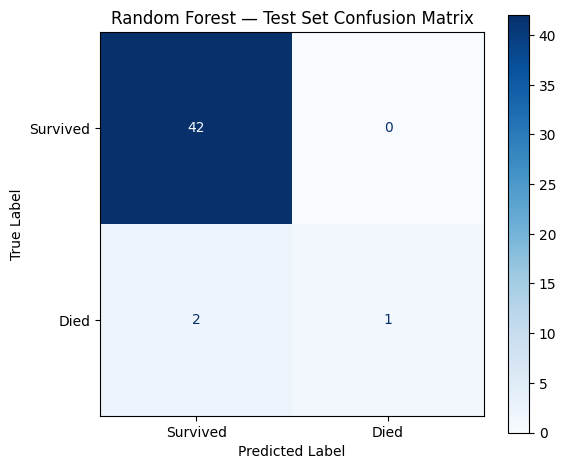

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix display
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_ml,
    y_test_pred,
    display_labels=["Survived", "Died"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Random Forest — Test Set Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

24.3 Plot Test-Set ROC Curve

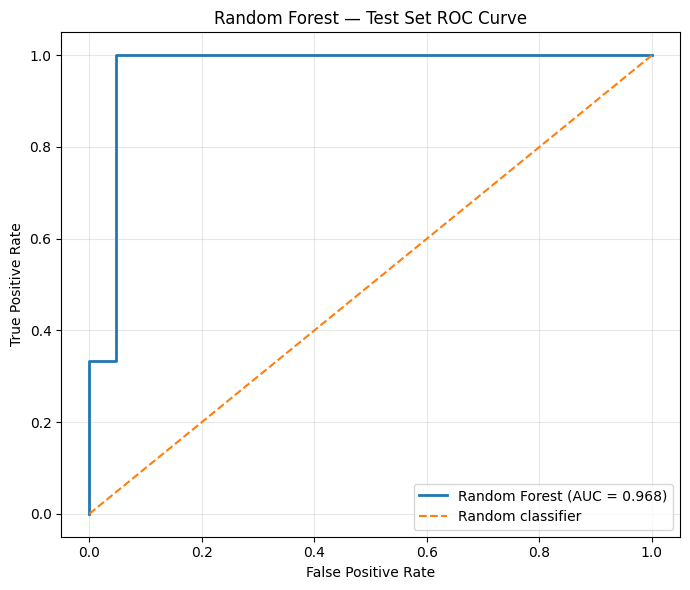

Test ROC-AUC: 0.9683


In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test_ml,
    y_test_prob
)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Create plot
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

# Reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — Test Set ROC Curve")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Test ROC-AUC: {roc_auc:.4f}")

24.4 Plot Top 20 Gene Importance

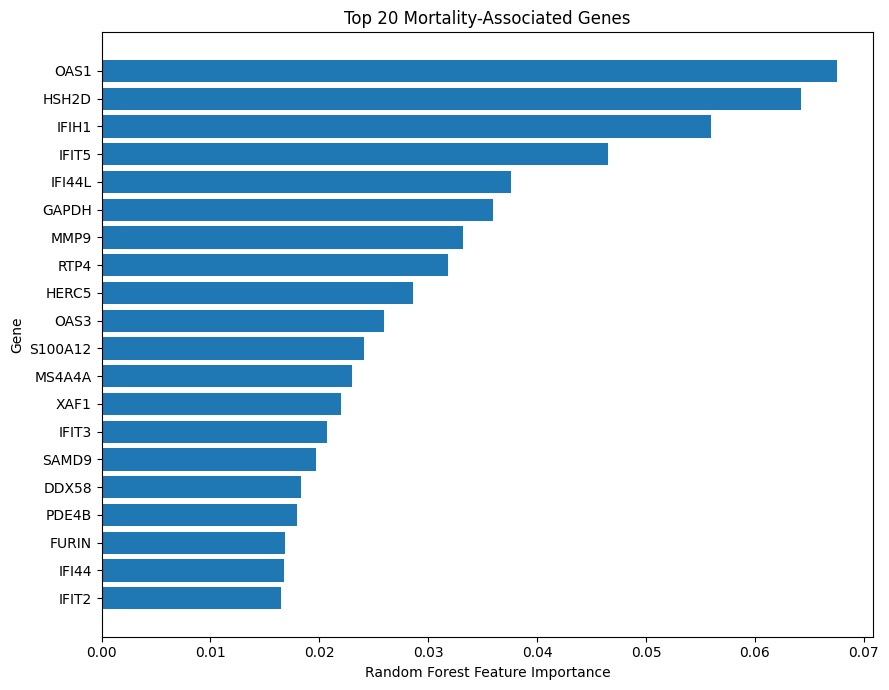

In [78]:
import matplotlib.pyplot as plt

# Take top 20 genes
top20 = feature_importance.head(20).copy()

# Reverse order so the most important gene
# appears at the top of the horizontal plot
top20 = top20.sort_values(
    "importance",
    ascending=True
)

# Create plot
plt.figure(figsize=(9, 7))

plt.barh(
    top20["gene"],
    top20["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Gene")
plt.title("Top 20 Mortality-Associated Genes")

plt.tight_layout()
plt.show()

24.5 Combine Gene Importance + DE Direction

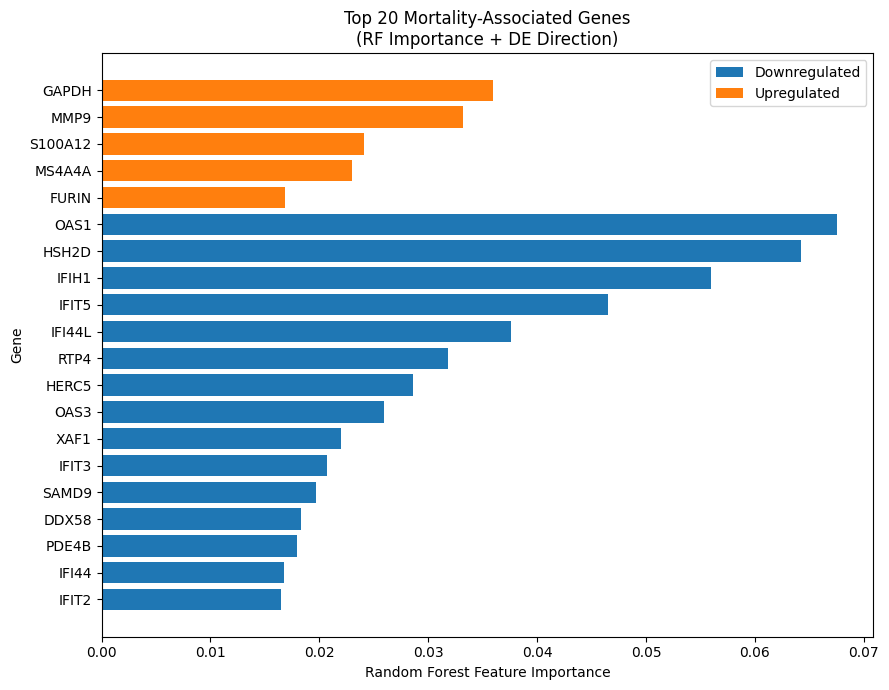

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 ML-important genes
plot_data = ml_gene_results.head(20).copy()

# Sort for horizontal plot
plot_data = plot_data.sort_values(
    "importance",
    ascending=True
)

# Create figure
plt.figure(figsize=(9, 7))

# Separate by expression direction
up = plot_data["direction"] == "Upregulated"
down = plot_data["direction"] == "Downregulated"

# Plot bars
plt.barh(
    plot_data.loc[down, "gene"],
    plot_data.loc[down, "importance"],
    label="Downregulated"
)

plt.barh(
    plot_data.loc[up, "gene"],
    plot_data.loc[up, "importance"],
    label="Upregulated"
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Gene")
plt.title("Top 20 Mortality-Associated Genes\n(RF Importance + DE Direction)")

plt.legend()
plt.tight_layout()
plt.show()

## 25. Export Final GitHub Results


In [80]:
# Export the final tables generated by the analysis.
# These files can be committed to the GitHub repository under results/.

import os

os.makedirs("results", exist_ok=True)

model_performance.to_csv(
    "results/model_performance.csv",
    index=False
)

top20_genes.to_csv(
    "results/top20_ml_genes.csv",
    index=False
)

significant_train.to_csv(
    "results/significant_genes.csv",
    index=False
)

print("✓ Final result tables exported to results/")
print("- model_performance.csv")
print("- top20_ml_genes.csv")
print("- significant_genes.csv")


✓ Final result tables exported to results/
- model_performance.csv
- top20_ml_genes.csv
- significant_genes.csv


## 26. Conclusion

This project investigated gene-expression patterns associated with mortality in pediatric patients with critical influenza using the GSE236877 dataset.

Differential expression analysis identified 122 mortality-associated candidate genes, including 46 upregulated and 76 downregulated genes. A Random Forest model was then developed using these candidate genes to explore their potential for distinguishing mortality from survival.

The model achieved strong overall discrimination on the independent test set, with an accuracy of 95.56% and a ROC-AUC of 0.9683. Several genes, including OAS1, HSH2D, IFIH1, IFIT5, IFI44L, MMP9, S100A12, and MS4A4A, were among the most important features identified by the model.

However, the mortality class was represented by only three samples in the test set, resulting in a recall of 33.3%. Therefore, the current findings should be considered exploratory rather than definitive evidence of clinical biomarker performance.

Overall, this analysis demonstrates a computational workflow for combining differential gene-expression analysis with machine learning to identify potential mortality-associated biomarkers in pediatric critical influenza. Further validation using larger and independent patient cohorts will be necessary to determine the robustness and clinical relevance of these candidate biomarkers.
